In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df1 = pd.read_excel('sales_report.xlsx', sheet_name='Order')
df1.head()

,Order ID,Order Date,CustomerName,State,City
0,B-25923,2018-12-27,Gopal,Maharashtra,Mumbai
1,B-25858,2018-11-13,Uudhav,Maharashtra,Mumbai
2,B-26099,2018-03-30,Bhishm,Maharashtra,Mumbai
3,B-25823,2018-10-18,Rohan,Maharashtra,Mumbai
4,B-25902,2018-12-10,Ishpreet,Maharashtra,Mumbai


In [3]:
df2 = pd.read_excel('sales_report.xlsx', sheet_name='Detail')
df2.head()

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,AOV
0,B-25696,275,-275,4,Clothing,Saree,COD,69
1,B-25675,929,-93,9,Clothing,Saree,COD,103
2,B-25650,512,-225,5,Clothing,Saree,COD,102
3,B-25787,556,-209,7,Clothing,Saree,COD,79
4,B-25691,714,56,4,Clothing,Saree,COD,179


In [4]:
df=pd.merge(df1,df2, on='Order ID', how='inner')

In [5]:
total_sales = df['Amount'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
profit_margin = (total_profit / total_sales) * 100

print("=== EXECUTIVE KPI SUMMARY ===")
print(f"Total Revenue:      ₹{total_sales:,.2f}")
print(f"Total Profit/Loss:  ₹{total_profit:,.2f}")
print(f"Profit Margin:      {profit_margin:.2f}%")
print(f"Total Unique Orders: {total_orders:,}")

=== EXECUTIVE KPI SUMMARY ===
Total Revenue:      ₹437,771.00
Total Profit/Loss:  ₹36,963.00
Profit Margin:      8.44%
Total Unique Orders: 500


In [6]:
# Find sub-categories with negative net profit
loss_subcats = df.groupby('Sub-Category')['Profit'].sum()
loss_subcats = loss_subcats[loss_subcats < 0].reset_index()

print("=== LOSS-MAKING SUB-CATEGORIES ===")
print(loss_subcats.to_string(index=False))

=== LOSS-MAKING SUB-CATEGORIES ===
    Sub-Category  Profit
Electronic Games    -644
     Furnishings    -806
           Kurti    -401
        Leggings    -130
           Skirt    -315


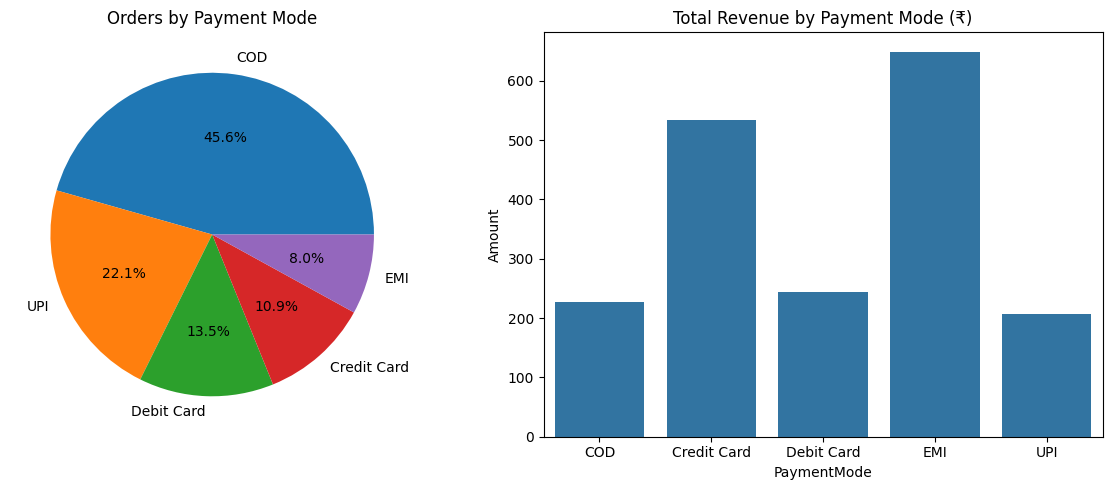

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Donut Chart - Orders by Payment Mode
payment_counts = df['PaymentMode'].value_counts()
axes[0].pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%')
axes[0].set_title('Orders by Payment Mode')

# 2. Bar Chart - Total Sales by Payment Mode
sns.barplot(data=df, x='PaymentMode', y='Amount', errorbar=None, ax=axes[1])
axes[1].set_title('Total Revenue by Payment Mode (₹)')

plt.tight_layout()
plt.show()

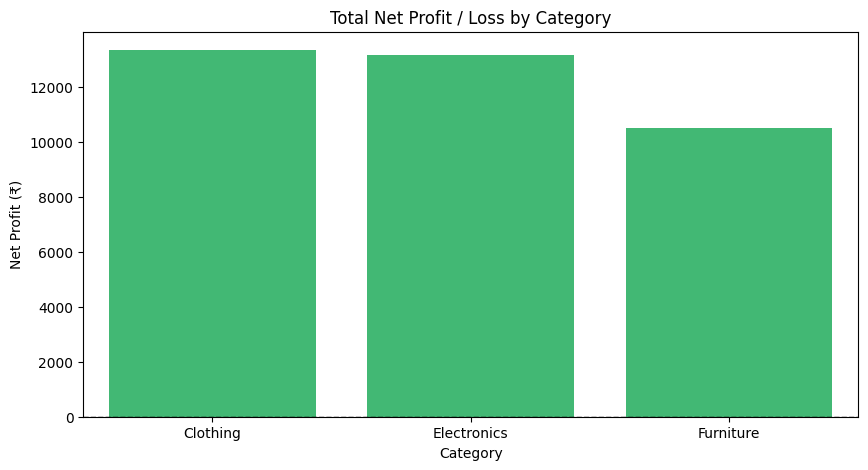

In [8]:
plt.figure(figsize=(10, 5))
category_profit = df.groupby('Category')['Profit'].sum().reset_index()

colors = ['#2ecc71' if x >= 0 else '#e74c3c' for x in category_profit['Profit']]

# Updated with hue='Category' and legend=False
sns.barplot(data=category_profit, x='Category', y='Profit', hue='Category', palette=colors, legend=False)

plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.title('Total Net Profit / Loss by Category')
plt.xlabel('Category')
plt.ylabel('Net Profit (₹)')
plt.show()

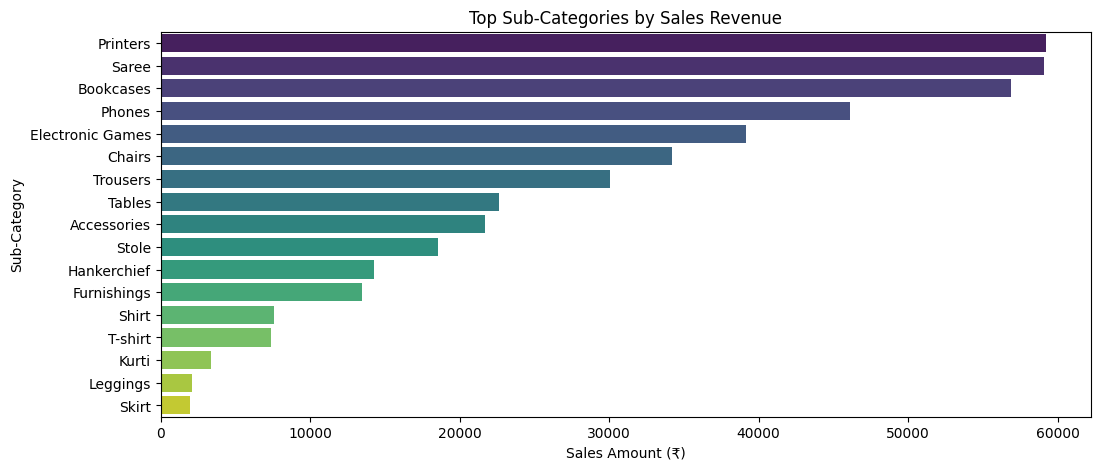

In [9]:
sub_cat = df.groupby('Sub-Category').agg({'Amount': 'sum', 'Profit': 'sum'}).reset_index()
sub_cat['Profit Margin (%)'] = (sub_cat['Profit'] / sub_cat['Amount']) * 100
sub_cat = sub_cat.sort_values(by='Amount', ascending=False)

plt.figure(figsize=(12, 5))

# Updated with hue='Sub-Category' and legend=False
sns.barplot(data=sub_cat, x='Amount', y='Sub-Category', hue='Sub-Category', palette='viridis', legend=False)

plt.title('Top Sub-Categories by Sales Revenue')
plt.xlabel('Sales Amount (₹)')
plt.show()

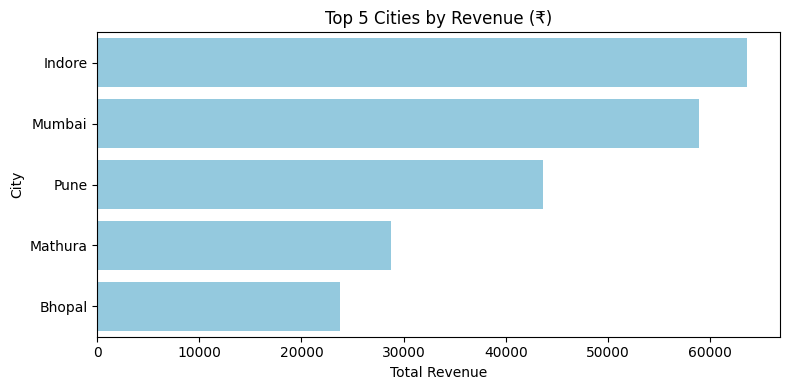

In [10]:
# Top 5 Cities
top_cities = df.groupby('City')['Amount'].sum().nlargest(5).reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(data=top_cities, x='Amount', y='City', color='skyblue')
plt.title('Top 5 Cities by Revenue (₹)')
plt.xlabel('Total Revenue')
plt.ylabel('City')
plt.tight_layout()
plt.show()